# Raw Data Exploration

**Question**: What do we have? Before writing loading or cleaning code, we need to understand the raw files: their structure, formats, units, quirks, and potential problems.

**Why this notebook exists**: Every decision in `data_loader.py` should trace back to something discovered here. If we multiply by 1e6, it's because we found the units here. If we parse WKT, it's because we saw the format here. Nothing should be assumed.

**Rule**: This notebook uses only `pd.read_csv()`, `pd.read_excel()`, and basic Python. No `data_loader.py`, no `schemas.py`. We are looking at the data as delivered.

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import ast
from pathlib import Path

PROJECT_ROOT = Path.cwd()
PROJECT_ROOT = PROJECT_ROOT.parent
print(PROJECT_ROOT)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
REFERENCE_DATA_DIR = PROJECT_ROOT / "data" / "reference"

RADNETT_RAW_PATH = next(RAW_DATA_DIR.glob("Radnett_AlleStasjoner_Overv*kingsdata_2023.csv"))
STATION_LOCATIONS_PATH = next(RAW_DATA_DIR.glob("Radnett*stasjoner*lokasjon.xlsx"))
CIVIL_DEFENCE_RAW_PATH = next(RAW_DATA_DIR.glob("Sivilforsvaret_M*lingsdata.csv"))
REPORT_STATION_PATH = REFERENCE_DATA_DIR / "dsa_report_table1_radnett.csv"
REPORT_AIRFILTER_PATH = REFERENCE_DATA_DIR / "dsa_report_table2_airfilter.csv"


pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 60)

/Users/anderskielland/Documents/Søknader/jobb_søk/JobbSøk6/DSA/intervju_tasks/Radiation


---
## Part 1: Radnett Monitoring Data
### 1.1 First look

In [2]:
# encoding="utf-8-sig" handles the BOM (byte order mark) Windows CSV exports add
radnett_raw = pd.read_csv(
    RADNETT_RAW_PATH,
    encoding="utf-8-sig"

)

print("First 5 rows:")
print(radnett_raw.head().to_string())
print("\nLast 5 rows:")
print(radnett_raw.tail().to_string())
print(f"\nShape: {radnett_raw.shape}")

First 5 rows:
   Station Code          Station Name              Time  Dose rate [microSv/h]
0             3  Østerås (Luftfilter)  01.01.2023 00:00                    0.0
1             3  Østerås (Luftfilter)  01.01.2023 01:00                    0.0
2             3  Østerås (Luftfilter)  01.01.2023 02:00                    0.0
3             3  Østerås (Luftfilter)  01.01.2023 03:00                    0.0
4             3  Østerås (Luftfilter)  01.01.2023 04:00                    0.0

Last 5 rows:
        Station Code         Station Name              Time  Dose rate [microSv/h]
385479            61  Mobil målestasjon 6  31.12.2023 20:00                    0.0
385480            61  Mobil målestasjon 6  31.12.2023 21:00                    0.0
385481            61  Mobil målestasjon 6  31.12.2023 22:00                    0.0
385482            61  Mobil målestasjon 6  31.12.2023 23:00                    0.0
385483            61  Mobil målestasjon 6  01.01.2024 00:00                    0.0


**Observations**:
- 4 columns: Station Code, Station Name, Time, Dose rate
- Air-filter is presented as hourly frequency, which is not the frequency of data generation
- Zero inflated? 

### 1.2 Column types and basic statistics

In [3]:
print("Column types as pandas read them:")
print(radnett_raw.dtypes)
print(f"\nMissing per column:")
print(radnett_raw.isna().sum())
print(f"\nDose rate statistics:")
print(radnett_raw["Dose rate [microSv/h]"].describe())

Column types as pandas read them:
Station Code               int64
Station Name                 str
Time                         str
Dose rate [microSv/h]    float64
dtype: object

Missing per column:
Station Code             0
Station Name             0
Time                     0
Dose rate [microSv/h]    0
dtype: int64

Dose rate statistics:
count    385484.000000
mean          0.073059
std           0.046568
min           0.000000
25%           0.056000
50%           0.078000
75%           0.103000
max           0.261000
Name: Dose rate [microSv/h], dtype: float64


In [4]:
# Check for potential empty strings in cells that might be considered missing values but are not NaN
print("\nEmpty strings per column:")
print((radnett_raw == "").sum())


Empty strings per column:
Station Code             0
Station Name             0
Time                     0
Dose rate [microSv/h]    0
dtype: int64


**Note**: 
- `Time` is read as string —> needs parsing. 
- No missing (values/strings) found by pandas; but missing data may be coded as 0.

### 1.3 Station inventory

In [5]:
stations = radnett_raw["Station Name"].value_counts()
print(f"Unique stations: {len(stations)}")
print(f"\nReadings per station:")
print(stations.to_string())
print(f"\nAll same count? {stations.nunique() == 1}")
print(f"8761 hours = 365 days x 24h + 1 = complete structural year")

Unique stations: 44

Readings per station:
Station Name
Østerås (Luftfilter)     8761
Sola (Luftfilter)        8761
Svanhovd (Luftfilter)    8761
Skibotn (Luftfilter)     8761
Arendal                  8761
Oslo                     8761
Svanhovd                 8761
Hammerfest               8761
Tromsø                   8761
Karasjok                 8761
Longyearbyen             8761
Kjeller                  8761
Molde                    8761
Dombås                   8761
Vinje                    8761
Hol                      8761
Drevsjø                  8761
Hamar                    8761
Trondheim                8761
Lista                    8761
Stavern                  8761
Halden                   8761
Brønnøysund              8761
Snåsa                    8761
Mehamn                   8761
Førde                    8761
Harstad                  8761
Vardø                    8761
Bodø                     8761
Mo i Rana                8761
Bergen                   8761
Stavanger     

**Key finding**: Every station has exactly 8,761 rows. The data is *structurally complete* — every hour has a row. Missing data is hidden inside the values, not as missing rows.   
**Check** if Air filter station should have hourly measuring - the filter is replaced once a week or similar, but not every hour.  


### 1.4 Station types from naming convention

In [6]:
print("All station names:")
for name in sorted(radnett_raw["Station Name"].unique()):
    if "(Luftfilter)" in name:
        tag = "<-- AIR FILTER"
    elif "Mobil" in name:
        tag = "<-- MOBILE"
    else:
        tag = ""
    print(f"  {name:35s} {tag}")

n_filter = sum("(Luftfilter)" in n for n in radnett_raw["Station Name"].unique())
n_mobile = sum("Mobil" in n for n in radnett_raw["Station Name"].unique())
n_fixed = radnett_raw["Station Name"].nunique() - n_filter - n_mobile
print(f"\nFixed: {n_fixed}, Air filter: {n_filter}, Mobile: {n_mobile}")
print("But the DSA claim 33 fixed measurement stations?")


All station names:
  Arendal                             
  Bergen                              
  Bodø                                
  Brønnøysund                         
  Dombås                              
  Drevsjø                             
  Førde                               
  Haakonsvern                         
  Halden                              
  Hamar                               
  Hammerfest                          
  Harstad                             
  Hitra                               
  Hol                                 
  Karasjok                            
  Kautokeino                          
  Kjeller                             
  Lista                               
  Longyearbyen                        
  Mehamn                              
  Mo i Rana                           
  Mobil målestasjon 1                 <-- MOBILE
  Mobil målestasjon 2                 <-- MOBILE
  Mobil målestasjon 3                 <-- MOBILE
  Mobil målesta

**Check** if Air filter is only 4 - DSA report: 8   
**Check** if Fixe stations are 34 - DSA report: 33

### 1.5 Investigating zero values

Background radiation is always present (typically 0.05-0.15 uSv/h in Norway, ref: RadNett (Sanntidsdata)).   
A reading of exactly 0.000 means the detector was likely not reporting.

In [7]:
total = radnett_raw.groupby("Station Name").size()
zeros = radnett_raw[radnett_raw["Dose rate [microSv/h]"] == 0].groupby("Station Name").size()

print("Zero values per station (sorted by severity):")
print(f"  {'Station':35s} {'Zeros':>7s} / {'Total':>5s}  {'Pct':>7s}  Status")
print("  " + "-" * 75)

for station in zeros.sort_values(ascending=False).index:
    z = zeros[station]
    t = total[station]
    pct = z / t * 100
    if pct > 50:
        status = "OFFLINE"
    elif pct > 5:
        status = "OPERATIVE"
    else:
        status = "STABLE"
    print(f"  {station:35s} {z:5d} / {t:5d}  {pct:6.1f}%  {status}")

n_offline = sum(1 for s in zeros.index if zeros[s] / total[s] > 0.5)
n_operative = sum(1 for s in zeros.index if 0.05 < zeros[s] / total[s] <= 0.5)
n_stable = sum(1 for s in zeros.index if zeros[s] / total[s] <= 0.05)

print(f"\nOffline (>50% zeros): {n_offline} stations")
print(f"Operative (5-50% zeros): {n_operative} stations")
print(f"Stable (<5% zeros): {n_stable} stations")

Zero values per station (sorted by severity):
  Station                               Zeros / Total      Pct  Status
  ---------------------------------------------------------------------------
  Mobil målestasjon 1                  8761 /  8761   100.0%  OFFLINE
  Lista                                8761 /  8761   100.0%  OFFLINE
  Kjeller                              8293 /  8761    94.7%  OFFLINE
  Skibotn (Luftfilter)                 8075 /  8761    92.2%  OFFLINE
  Mobil målestasjon 6                  7904 /  8761    90.2%  OFFLINE
  Mobil målestasjon 3                  7040 /  8761    80.4%  OFFLINE
  Runde                                6084 /  8761    69.4%  OFFLINE
  Haakonsvern                          5262 /  8761    60.1%  OFFLINE
  Førde                                4721 /  8761    53.9%  OFFLINE
  Østerås (Luftfilter)                 4540 /  8761    51.8%  OFFLINE
  Bodø                                 3351 /  8761    38.2%  OPERATIVE
  Sola (Luftfilter)              

**This is the most important finding in the entire exploration.**

Zero values = missing data, not zero radiation. Some stations were completely offline.   
**Notice** Compare with official data from DSA report over year 2023.

### 1.6 Visual comparison: healthy vs failing station

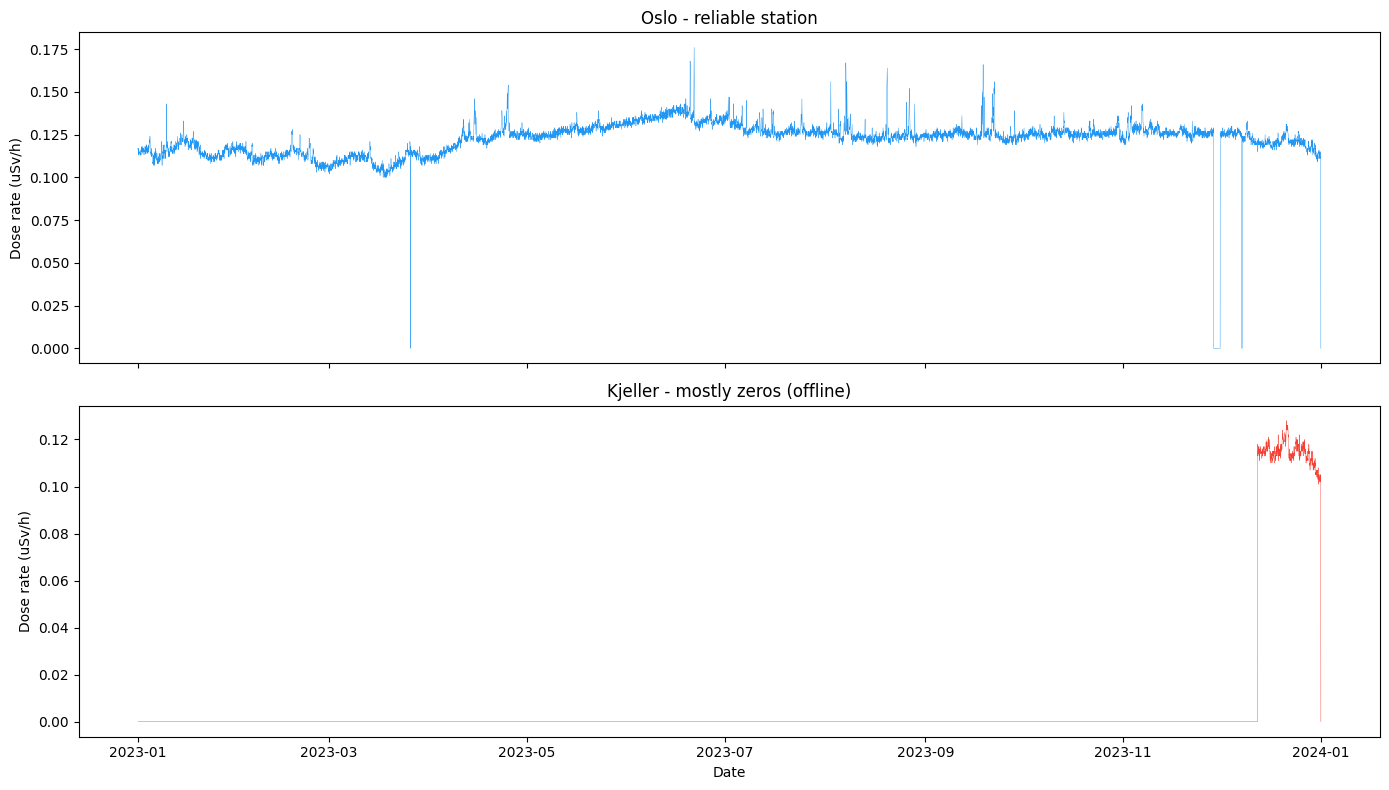

Oslo shows seasonal pattern (lower in winter = snow shielding) and spikes (radon washout)
Kjeller is flat at zero with brief data periods - confirms offline, not zero radiation


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

oslo = radnett_raw[radnett_raw["Station Name"] == "Oslo"].copy()
oslo["t"] = pd.to_datetime(oslo["Time"], format="%d.%m.%Y %H:%M")
axes[0].plot(oslo["t"], oslo["Dose rate [microSv/h]"], lw=0.3, color="#2196F3")
axes[0].set_ylabel("Dose rate (uSv/h)")
axes[0].set_title("Oslo - reliable station")

kjeller = radnett_raw[radnett_raw["Station Name"] == "Kjeller"].copy()
kjeller["t"] = pd.to_datetime(kjeller["Time"], format="%d.%m.%Y %H:%M")
axes[1].plot(kjeller["t"], kjeller["Dose rate [microSv/h]"], lw=0.3, color="#F44336")
axes[1].set_ylabel("Dose rate (uSv/h)")
axes[1].set_title("Kjeller - mostly zeros (offline)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

print("Oslo shows seasonal pattern (lower in winter = snow shielding) and spikes (radon washout)")
print("Kjeller is flat at zero with brief data periods - confirms offline, not zero radiation")

### 1.7 Time format verification

In [9]:
sample_time = radnett_raw["Time"].iloc[0]
parsed = pd.to_datetime(sample_time, format="%d.%m.%Y %H:%M")
print(f"Raw: {sample_time!r}")
print(f"Format string for pandas: %d.%m.%Y %H:%M")
print("Parsed:" + str(parsed))
parsed

Raw: '01.01.2023 00:00'
Format string for pandas: %d.%m.%Y %H:%M
Parsed:2023-01-01 00:00:00


Timestamp('2023-01-01 00:00:00')

### 1.8 Non-zero dose rate distribution

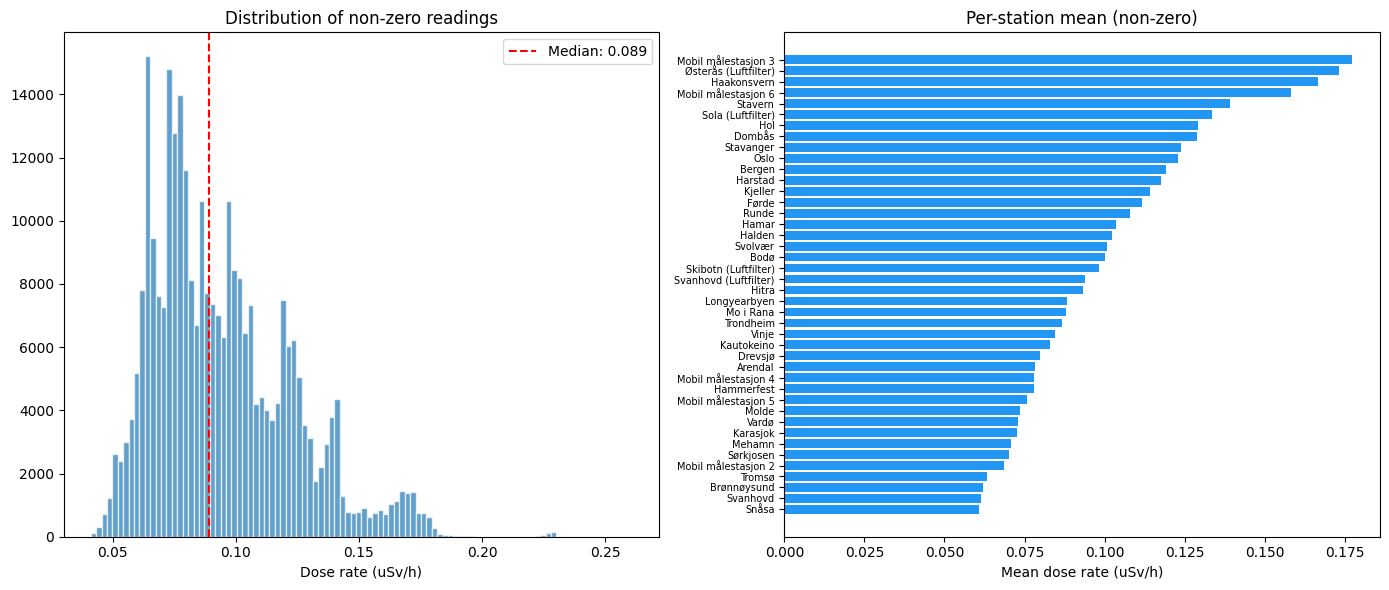

Range: 0.0410 to 0.2610 uSv/h - all within normal background


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

nonzero = radnett_raw[radnett_raw["Dose rate [microSv/h]"] > 0]["Dose rate [microSv/h]"]
axes[0].hist(nonzero, bins=100, edgecolor="white", alpha=0.7)
axes[0].set_xlabel("Dose rate (uSv/h)")
axes[0].set_title("Distribution of non-zero readings")
axes[0].axvline(nonzero.median(), color="red", ls="--", label=f"Median: {nonzero.median():.3f}")
axes[0].legend()

means = radnett_raw[radnett_raw["Dose rate [microSv/h]"] > 0].groupby("Station Name")["Dose rate [microSv/h]"].mean().sort_values()
axes[1].barh(range(len(means)), means.values, color="#2196F3")
axes[1].set_yticks(range(len(means)))
axes[1].set_yticklabels(means.index, fontsize=7)
axes[1].set_xlabel("Mean dose rate (uSv/h)")
axes[1].set_title("Per-station mean (non-zero)")

plt.tight_layout()
plt.show()
print(f"Range: {nonzero.min():.4f} to {nonzero.max():.4f} uSv/h - all within normal background")

---
## Part 2: Station Locations

### 2.1 Raw file

In [11]:
loc_raw = pd.read_excel(STATION_LOCATIONS_PATH, engine="openpyxl")
print(loc_raw.to_string())
print(f"\nColumn types:")
print(loc_raw.dtypes)

                  Stasjon    VertPos    HorzPos
0    Østerås (Luftfilter)  59.947940  10.602880
1       Sola (Luftfilter)  58.880841   5.645943
2   Svanhovd (Luftfilter)  69.455132  30.040915
3                 Svolvær  68.232198  14.562573
4    Skibotn (Luftfilter)  69.371735  20.303785
5                   Runde  62.398990   5.660660
6                 Arendal  58.476399   8.817814
7                    Oslo  59.943100  10.721150
8                Svanhovd  69.455161  30.041229
9              Hammerfest  70.671266  23.666003
10                 Tromsø  69.653669  18.936566
11               Karasjok  69.463515  25.502517
12           Longyearbyen  78.222626  15.624433
13                Kjeller  59.976139  11.050119
14                  Hitra  63.638532   8.687296
15             Kautokeino  69.021938  23.019255
16            Haakonsvern  60.335540   5.234538
17              Sørkjosen  69.785608  20.941505
18    Mobil målestasjon 1  59.947950  10.602830
19    Mobil målestasjon 2  60.000000  10

**Notice:** Stavanger was string in excel file, but Pandas transformed to float.

### 2.2 Coordinate type check

In [12]:
print("Checking for non-float coordinates:")
found = False
for _, row in loc_raw.iterrows():
    lt = type(row["VertPos"]).__name__
    lo = type(row["HorzPos"]).__name__
    if lt != "float" or lo != "float":
        found = True
        print(f"  {row['Stasjon']:35s} lat={row['VertPos']!r} ({lt}), lon={row['HorzPos']!r} ({lo})")
if not found:
    print("  All coordinates are float")
else:
    print("\n--> Pipeline must use pd.to_numeric() to force float types")

Checking for non-float coordinates:
  All coordinates are float


### 2.3 Duplicate (or placeholder coordinates)

In [13]:
groups = loc_raw.groupby(["VertPos", "HorzPos"])["Stasjon"].apply(list)
dupes = groups[groups.apply(len) > 1]
if len(dupes) > 0:
    print("Shared coordinates:")
    for (lat, lon), names in dupes.items():
        print(f"  ({lat}, {lon}): {names}")
    print("\n--> Placeholder coords for mobile stations. Must flag in pipeline.")
else:
    print("No duplicates found")

Shared coordinates:
  (60.0, 10.0): ['Mobil målestasjon 2', 'Mobil målestasjon 3', 'Mobil målestasjon 4', 'Mobil målestasjon 5', 'Mobil målestasjon 6']

--> Placeholder coords for mobile stations. Must flag in pipeline.


In [14]:
dupes

VertPos  HorzPos
60.0     10.0       [Mobil målestasjon 2, Mobil målestasjon 3, Mobil målestasjon 4, Mobil målestasjon 5, Mobil målestasjon 6]
Name: Stasjon, dtype: object

### 2.4 Station name matching

In [15]:
r_names = set(radnett_raw["Station Name"].unique())
l_names = set(loc_raw["Stasjon"].unique())
diff1 = r_names - l_names
diff2 = l_names - r_names
if not diff1 and not diff2:
    print(f"All {len(r_names)} station names match perfectly.")
else:
    print(f"In Radnett only: {diff1}")
    print(f"In locations only: {diff2}")

All 44 station names match perfectly.


---
## Part 3: Civil Defence Data

Most complex dataset — several parsing challenges.   
**Notice** there are some string values that should have been numbers in the raw csv file, but these are handel by pandas import 

### 3.1 First look

In [16]:
civil_raw = pd.read_csv(CIVIL_DEFENCE_RAW_PATH)
print(f"Shape: {civil_raw.shape}")
print("\nFirst row:")
print(civil_raw.head(1).to_string())
print("\nFirst row (transposed):")
print(civil_raw.head(1).T.to_string())
print(f"\nColumn types:")
print(civil_raw.dtypes)

Shape: (2356, 9)

First row:
                                                location  doserate [Sv/h]                  timestamp  measurement_height                                                                                                                                                                                                                                                                                                                               metadata       session             team           event measurement_type
0  SRID=4326;POINT(7.738536126722629 63.127726870202274)     5.900000e-08  2022-02-15 07:53:00+00:00                 1.0  {'comment': None, 'rainfall': False, 'message_id': 'd22ca961c61c4c5b8fa387e01778a13e', 'snow_depth': 0.0, 'measurement_id': '82ea700d63e64598afffefc733e3be47', 'instrument_number': None, 'measuring_point_id': '000119', 'last_uploaded_to_dsa': '2022-03-01 08:00:00.436490', 'measuring_point_name': 'Folkeparken, Kristiansund'}  PLIS PL027

### 3.2 Location column — parsing WKT coordinates

Format: `SRID=4326;POINT(longitude latitude)`. **Longitude first** (WKT standard for GIS - x/y).  
We don't care about SRID here.

In [17]:
print("Sample locations:")
for i in range(3):
    print(f"  {civil_raw['location'].iloc[i]}")

# Manual parse of first entry
sample = civil_raw["location"].iloc[0]
match = re.search(r"POINT\(([-\d.]+)\s+([-\d.]+)\)", sample)
lon, lat = float(match.group(1)), float(match.group(2))
print(f"\nParsed: lon={lon:.4f}, lat={lat:.4f}")
print("Inside POINT(), longitude comes FIRST, latitude SECOND")

Sample locations:
  SRID=4326;POINT(7.738536126722629 63.127726870202274)
  SRID=4326;POINT(8.037315562804698 63.02881998914563)
  SRID=4326;POINT(7.75123927785748 63.02956515405165)

Parsed: lon=7.7385, lat=63.1277
Inside POINT(), longitude comes FIRST, latitude SECOND


### 3.3 Parse all coordinates and find problems
Used coordinate range to capture all of Norway (included Svalbard): latitude (55, 82), longitude (3, 35).  
- Outside range is flagged as Corr error   
- 0.0 is flagged as Missing recording.

In [18]:
def parse_point(s):
    try:
        m = re.search(r"POINT\(([-\d.]+)\s+([-\d.]+)\)", s)
        if m:
            return float(m.group(2)), float(m.group(1))
    except Exception:
        pass
    return np.nan, np.nan

coords = civil_raw["location"].apply(parse_point)
civil_raw["lat"] = coords.apply(lambda x: x[0])
civil_raw["lon"] = coords.apply(lambda x: x[1])

print(f"Lat range: {civil_raw['lat'].min():.4f} to {civil_raw['lat'].max():.4f}")
print(f"Lon range: {civil_raw['lon'].min():.4f} to {civil_raw['lon'].max():.4f}")

# Flag problems
suspect = civil_raw[
    (civil_raw["lat"] < 55) | (civil_raw["lat"] > 82) |
    (civil_raw["lon"] < 3) | (civil_raw["lon"] > 35)
]
print(f"\nCoordinates outside Norway/Svalbard: {len(suspect)}")
for _, row in suspect.iterrows():
    try:
        meta = ast.literal_eval(row["metadata"])
        name = meta.get("measuring_point_name", "?")
    except Exception:
        name = "?"
    issue = "Missing (0,0)" if row["lat"] == 0 else "Coord error"
    print(f"  ({row['lon']:8.4f}, {row['lat']:8.4f}) | {name:40s} | {issue}")

Lat range: 0.0000 to 71.0642
Lon range: 0.0000 to 57.2413

Coordinates outside Norway/Svalbard: 13
  (  0.0000,   0.0000) | Klungset, Fauske                         | Missing (0,0)
  (  2.7898,  60.2653) | Uvdal, Nore og Uvdal                     | Coord error
  (  0.0000,   0.0000) | Horn Brønnøysund                         | Missing (0,0)
  ( 57.1619,   1.8306) | Leirvik, Stord                           | Coord error
  ( 57.2413,   1.7761) | Rimbareid, Fitjar                        | Coord error
  (  0.0000,   0.0000) | Båsmo barnehage parkering nord           | Missing (0,0)
  (  2.7898,  60.2653) | Uvdal, Nore og Uvdal                     | Coord error
  (  0.0000,   0.0000) | Båsmo barnehage parkering nord           | Missing (0,0)
  (  0.0000,   0.0000) | Horn Brønnøysund                         | Missing (0,0)
  (  0.0000,   0.0000) | Båsmo barnehage parkering nord           | Missing (0,0)
  (  0.0000,   0.0000) | Båsmo barnehage parkering nord           | Missing (0,0)
  (  0.

### 3.4 Dose rate units — comparing RAdnet and Civil Defence

Radnett uses **µSv/h**. Civil Defence uses **Sv/h**. Factor 1,000,000 difference.

In [19]:
print("Raw Civil Defence dose rate (Sv/h):")
print(civil_raw["doserate [Sv/h]"].describe())

civil_raw["dose_microsv"] = civil_raw["doserate [Sv/h]"] * 1e6
print(f"\nConverted to uSv/h:")
print(civil_raw["dose_microsv"].describe())

r_median = radnett_raw[radnett_raw["Dose rate [microSv/h]"] > 0]["Dose rate [microSv/h]"].median()
c_median = civil_raw["dose_microsv"].median()
print(f"\nSanity check:")
print(f"  Radnett median:       {r_median:.4f} uSv/h")
print(f"  Civil Defence median: {c_median:.4f} uSv/h")
print(f"  Same order of magnitude: {0.3 < r_median/c_median < 3.0}")

Raw Civil Defence dose rate (Sv/h):
count    2.356000e+03
mean     7.268175e-08
std      9.305513e-08
min      0.000000e+00
25%      5.600000e-08
50%      6.800000e-08
75%      8.200000e-08
max      4.350000e-06
Name: doserate [Sv/h], dtype: float64

Converted to uSv/h:
count    2356.000000
mean        0.072682
std         0.093055
min         0.000000
25%         0.056000
50%         0.068000
75%         0.082000
max         4.350000
Name: dose_microsv, dtype: float64

Sanity check:
  Radnett median:       0.0890 uSv/h
  Civil Defence median: 0.0680 uSv/h
  Same order of magnitude: True


### 3.5 Metadata column — what is hidden in there?

In [20]:
# Parse one entry to see the structure
sample = ast.literal_eval(civil_raw["metadata"].iloc[0])
print("Metadata keys and types:")
for k, v in sample.items():
    print(f"  {k:30s} = {v!r:40s} ({type(v).__name__})")

# Check if ALL entries parse
ok, fail = 0, 0
rain_counts = {}
for s in civil_raw["metadata"]:
    try:
        p = ast.literal_eval(s)
        ok += 1
        r = p.get("rainfall")
        rain_counts[r] = rain_counts.get(r, 0) + 1
    except:
        fail += 1

print(f"\nParsing: {ok} success, {fail} failures")
print(f"Rainfall flag: {rain_counts}")
print(f"\n--> {rain_counts.get(True, 0)} measurements during rain ")
print(f"--> Analytically valuable for radon washout analysis")

Metadata keys and types:
  comment                        = None                                     (NoneType)
  rainfall                       = False                                    (bool)
  message_id                     = 'd22ca961c61c4c5b8fa387e01778a13e'       (str)
  snow_depth                     = 0.0                                      (float)
  measurement_id                 = '82ea700d63e64598afffefc733e3be47'       (str)
  instrument_number              = None                                     (NoneType)
  measuring_point_id             = '000119'                                 (str)
  last_uploaded_to_dsa           = '2022-03-01 08:00:00.436490'             (str)
  measuring_point_name           = 'Folkeparken, Kristiansund'              (str)

Parsing: 2356 success, 0 failures
Rainfall flag: {False: 1924, True: 431, None: 1}

--> 431 measurements during rain 
--> Analytically valuable for radon washout analysis


### 3.6 Time range

In [21]:
civil_raw["time_parsed"] = pd.to_datetime(civil_raw["timestamp"])
print(f"Range: {civil_raw['time_parsed'].min()} to {civil_raw['time_parsed'].max()}")
print(f"\nPer year:")
print(civil_raw["time_parsed"].dt.year.value_counts().sort_index())

Range: 2002-06-10 06:15:00+00:00 to 2024-06-13 10:51:00+00:00

Per year:
time_parsed
2002       1
2021       6
2022    1014
2023     944
2024     391
Name: count, dtype: int64


### 3.7 Extreme values

In [22]:
print("Top 10 highest readings (uSv/h):")
top = civil_raw.nlargest(10, "dose_microsv")
for _, row in top.iterrows():
    try:
        m = ast.literal_eval(row["metadata"])
        name = m.get("measuring_point_name", "NO NAME")
        rain = m.get("rainfall", "?")
    except:
        name, rain = "?", "?"
    print(f"  {row['dose_microsv']:.4f} | {str(row['timestamp'])[:10]} | rain={str(rain):5s} | {name}")

print(f"\nHighest is {civil_raw['dose_microsv'].max():.0f}x the median - needs investigation")

Top 10 highest readings (uSv/h):
  4.3500 | 2023-04-20 | rain=?     | NO NAME
  0.7000 | 2023-10-18 | rain=False | Storvannet, HAmmerfest
  0.5500 | 2023-09-04 | rain=False | Halne, Eidfjord
  0.2800 | 2022-12-15 | rain=False | Caravan-plass, Strand, Sortland
  0.2400 | 2022-12-15 | rain=False | Sortland, Vikveien 347
  0.2180 | 2023-11-02 | rain=False | Svortland, Bømlo
  0.2100 | 2022-12-15 | rain=False | Sortland, Slalombakken
  0.2050 | 2023-08-07 | rain=True  | Jamne, Vaksdal
  0.1930 | 2023-11-17 | rain=False | Høyfjell,
  0.1910 | 2022-02-18 | rain=True  | Jørpeland,

Highest is 4x the median - needs investigation


In [23]:
# Extract the single highest measurement for investigation
outlier = civil_raw.loc[civil_raw["dose_microsv"].idxmax()]

print("=== HIGHEST MEASUREMENT ===")
print(f"dose_microsv      : {outlier['dose_microsv']:.4f} uSv/h")
print(f"doserate [Sv/h]   : {outlier['doserate [Sv/h]']:.2e}")
print(f"timestamp         : {outlier['timestamp']}")
print(f"lon / lat         : {outlier['lon']:.4f} / {outlier['lat']:.4f} ")
print(f"team              : {outlier['team']}")
print(f"measurement_type  : {outlier['measurement_type']}")
print(f"event             : {outlier['event']}")

try:
    m = ast.literal_eval(outlier["metadata"])
    print(f"\n--- metadata ---")
    for k, v in m.items():
        print(f"  {k:30s}: {v}")
except Exception:
    print(f"metadata (raw)    : {outlier['metadata']}")

median = civil_raw["dose_microsv"].median()
print(f"\nMedian across all rows : {median:.4f} uSv/h")
print(f"This outlier is        : {outlier['dose_microsv'] / median:.0f}x the median")

=== HIGHEST MEASUREMENT ===
dose_microsv      : 4.3500 uSv/h
doserate [Sv/h]   : 4.35e-06
timestamp         : 2023-04-20 11:48:00+00:00
lon / lat         : 14.2588 / 67.0689 
team              : DSB RADIAK PLIS
measurement_type  : FOT
event             : Sivilforsvaret

--- metadata ---
  comment                       : 
  location_accuracy_m           : 4.714293999835326

Median across all rows : 0.0680 uSv/h
This outlier is        : 64x the median


### 3.8 Other columns

In [24]:
print("measurement_height:", civil_raw["measurement_height"].value_counts().to_dict())
print("measurement_type:", civil_raw["measurement_type"].value_counts().to_dict())
print("event:", civil_raw["event"].value_counts().to_dict())
print(f"Unique teams: {civil_raw['team'].nunique()}")
print(civil_raw["team"].value_counts().to_string())
print("\n--> All FOT (on foot), all Sivilforsvaret, height 1.0 or 1.5m")

measurement_height: {1.0: 2321, 1.5: 35}
measurement_type: {'FOT': 2356}
event: {'Sivilforsvaret': 2356}
Unique teams: 1
team
DSB RADIAK PLIS    2356

--> All FOT (on foot), all Sivilforsvaret, height 1.0 or 1.5m


---
## Part 4: Cross-checking against DSA Report for year 2023 (2024:04)

The DSA annual report contains two key tables:
- **Table 1**: All 33 Radnett stations with coordinates (degrees/minutes) and placement type
- **Table 2**: All 9 air filter stations with coordinates (decimal) and equipment details

We cross-check the data file against both tables to find discrepancies.

Reference data manually extracted and saved as:
- `data/reference/dsa_report_table1_radnett.csv`
- `data/reference/dsa_report_table2_airfilter.csv`  

The report also contains placement for the fixed stations: `ground` (bakkennivå) vs `building` (bygning). This is critical for our analysis — building-mounted stations don't show seasonal snow-shielding effects. Stations on buildings:
Hammerfest, Sørkjosen, Svolvær, Bodø, Mo i Rana, Bergen, Halden.

**For the pipeline**: We should add the `placement` column from the report to our station data.

### 4.1 Station count: 33 vs 34

In [25]:
# Count stations by type in the data file
data_names = set(radnett_raw["Station Name"].unique())
air_filter_names = {n for n in data_names if "(Luftfilter)" in n}
mobile_names = {n for n in data_names if "Mobil" in n}
fixed_names = data_names - air_filter_names - mobile_names

# Load report Table 1
table1 = pd.read_csv("../data/reference/dsa_report_table1_radnett.csv", comment="#") # pd.read_csv(REPORT_STATION_PATH, comment="#")
table1_names = set(table1["station_name"].unique())

print(f"Data file: {len(data_names)} total stations")
print(f"  Fixed: {len(fixed_names)}")
print(f"  Air filter (tagged): {len(air_filter_names)}")
print(f"  Mobile: {len(mobile_names)}")
print(f"\nReport Table 1: {len(table1_names)} Radnett stations")
print(f"\nIn data (fixed) but NOT in Report Table 1:")
for n in sorted(fixed_names - table1_names):
    print(f"  {n}")
print(f"\nIn Report Table 1 but NOT in data:")
missing = table1_names - fixed_names
if missing:
    for n in sorted(missing): print(f"  {n}")
else:
    print("  (none — all 33 report stations are in the data)")

Data file: 44 total stations
  Fixed: 34
  Air filter (tagged): 4
  Mobile: 6

Report Table 1: 33 Radnett stations

In data (fixed) but NOT in Report Table 1:
  Haakonsvern

In Report Table 1 but NOT in data:
  (none — all 33 report stations are in the data)


**Finding**: The data has **34 fixed stations**, but the report lists **33**. The extra station is **Haakonsvern** — a Norwegian naval base near Bergen. It is not mentioned in the DSA annual report, possibly because it is a military installation or because it is not formally part of the Radnett network.

### 4.2 Air filter stations: data vs Report Table 2

The report lists 9 air filter stations (Table 2). The data file only tags 4 stations with `(Luftfilter)`. What happened to the other 5?

In [26]:
# Load report Table 2
table2 = pd.read_csv("../data/reference/dsa_report_table2_airfilter.csv", comment="#") # pd.read_csv(REPORT_AIRFILTER_PATH, comment="#")

print("Report Table 2 - Air filter stations:")
print(table2[["station_name", "lat_decimal", "lon_decimal", "charcoal_filter_iodine", "online_monitor"]].to_string(index=False))

# Compare with data
data_airfilter_base = {n.replace(" (Luftfilter)", "") for n in air_filter_names}
table2_names = set(table2["station_name"].unique())

print(f"\nData tags as (Luftfilter): {sorted(air_filter_names)}")
print(f"\nIn Table 2 but NOT tagged in data:")
for name in sorted(table2_names - data_airfilter_base):
    in_data = name in data_names or name in fixed_names
    print(f"  {name:20s} present in data as fixed station? {in_data}")

print(f"\nIn data (Luftfilter) but NOT in Table 2:")
for name in sorted(data_airfilter_base - table2_names):
    print(f"  {name}")

Report Table 2 - Air filter stations:
station_name  lat_decimal  lon_decimal charcoal_filter_iodine online_monitor
   Stavanger        58.88         5.63                     no            yes
     Østerås        59.94        10.60                    yes            yes
      Bergen        60.34         5.22                     no             no
      Ørland        63.70         9.62                     no             no
     Skibotn        69.36        20.30                     no            yes
    Svanhovd        69.45        30.04                    yes            yes
 Viksjøfjell        69.62        30.80                     no             no
      Tromsø        69.66        18.97                    yes             no
Longyearbyen        78.22        15.38                     no             no

Data tags as (Luftfilter): ['Skibotn (Luftfilter)', 'Sola (Luftfilter)', 'Svanhovd (Luftfilter)', 'Østerås (Luftfilter)']

In Table 2 but NOT tagged in data:
  Bergen               present in

**Findings**:

1. **Sola = Stavanger**: The data calls it `Sola (Luftfilter)`, the report calls it `Stavanger`. Same coordinates (~58.88, 5.63). Different naming convention.

2. **Bergen, Tromsø, Longyearbyen**: These locations have BOTH a Radnett dose rate detector AND an air filter station, but the data only tags them as fixed stations — not as `(Luftfilter)`. The `(Luftfilter)` tag in the data apparently means the air filter is the *primary* detector, not that an air filter exists there.

3. **Viksjøfjell and Ørland**: These have air filter stations but NO Radnett dose rate detector. They are completely absent from the data file. Their measurements come from weekly lab analysis, not continuous monitoring.

4. **Longyearbyen air filter**: Operated by NORSAR as part of the CTBT treaty network. DSA has access to the data but doesn't operate the station.

### 4.3 Coordinate cross-check (Table 1 vs location file)

In [27]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lon1, lat1, lon2, lat2):
    """Distance in km between two points. Arguments: lon1, lat1, lon2, lat2 (x, y order)."""
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# Load report reference (degrees + minutes from DSA Report 2024:04, Table 1)
report = pd.read_csv(REPORT_STATION_PATH, comment="#")
report["report_lat"] = report["lat_deg"] + report["lat_min"] / 60
report["report_lon"] = report["lon_deg"] + report["lon_min"] / 60

# Load file locations
loc = pd.read_excel(STATION_LOCATIONS_PATH, engine="openpyxl")
loc.columns = ["station_name", "latitude", "longitude"]
loc["latitude"] = pd.to_numeric(loc["latitude"], errors="coerce")
loc["longitude"] = pd.to_numeric(loc["longitude"], errors="coerce")

# Match and compare
resufor _, r_row in report.iterrows(
    name = r_row["station_name"]
    match = loc[loc["station_name"] == name]
    if len(match) == 0:
        continue
    f_lat = match.iloc[0]["latitude"]
    f_lon = match.iloc[0]["longitude"]
    dist = haversine_km(f_lon, f_lat, r_row["report_lon"], r_row["report_lat"])
    results.append({
        "station": name,
        "file_lat": f_lat,
        "file_lon": f_lon,
        "report_lat": r_row["report_lat"],
        "report_lon": r_row["report_lon"],
        "distance_km": dist,
        "placement": r_row["placement"],
    })

results_df = pd.DataFrame(results).sort_values("distance_km", ascending=False)
print("Cross-check: Location file vs DSA Report 2024:04, Table 1")
print("Sorted by distance (largest discrepancy first):\n")
for _, row in results_df.iterrows():
    flag = ""
    if row["distance_km"] > 10:
        flag = "*** MISMATCH ***"
    elif row["distance_km"] > 5:
        flag = "* check *"
    print(
        f"  {row['station']:<25s} file=({row['file_lat']:7.3f},{row['file_lon']:7.3f})  "
        f"report=({row['report_lat']:7.3f},{row['report_lon']:7.3f})  "
        f"{row['distance_km']:6.1f}km  {row['placement']:>8s}  {flag}"
    )

Cross-check: Location file vs DSA Report 2024:04, Table 1
Sorted by distance (largest discrepancy first):

  Kautokeino                file=( 69.022, 23.019)  report=( 69.583, 25.317)   109.8km    ground  *** MISMATCH ***
  Sørkjosen                 file=( 69.786, 20.942)  report=( 69.583, 20.967)    22.5km  building  *** MISMATCH ***
  Arendal                   file=( 58.476,  8.818)  report=( 58.517,  8.900)     6.5km    ground  * check *
  Snåsa                     file=( 64.259, 12.372)  report=( 64.233, 12.383)     2.9km    ground  
  Svolvær                   file=( 68.232, 14.563)  report=( 68.217, 14.583)     1.9km  building  
  Runde                     file=( 62.399,  5.661)  report=( 62.383,  5.650)     1.8km    ground  
  Vinje                     file=( 59.616,  7.855)  report=( 59.600,  7.850)     1.8km    ground  
  Hol                       file=( 60.580,  8.411)  report=( 60.567,  8.400)     1.6km    ground  
  Halden                    file=( 58.996, 11.528)  report=(

**Coordinate findings**:

1. **Kautokeino** (~110 km off): The report lists 69°35'N, 25°19'E — but Kautokeino is actually at ~69.01°N, 23.04°E. The data file is correct. The report's coordinates are near Karasjok. Note: the report gives the same latitude 69°35' for both Kautokeino and Sørkjosen, which is suspicious.

2. **Sørkjosen** (~22 km off): Similar issue — the report latitude appears wrong. The data file matches the real location.

3. **All other stations**: Within 3 km — normal for station-to-town-center distance.

**Bonus**: The `placement` column from Table 1 tells us which stations are ground-level (bakkenivå) vs building-mounted (bygning). Building stations: Hammerfest, Sørkjosen, Svolvær, Bodø, Mo i Rana, Bergen, Halden.

### 4.4 Air filter coordinate cross-check (Table 2)

In [28]:
# Table 2 uses decimal coords — check against location file where names match
print("Air filter stations — Table 2 vs location file:\n")

# Build a name mapping: Table 2 name -> data file name
name_map = {
    "Stavanger": "Sola (Luftfilter)",
    "Østerås": "Østerås (Luftfilter)",
    "Skibotn": "Skibotn (Luftfilter)",
    "Svanhovd": "Svanhovd (Luftfilter)",
    # These exist as fixed stations in the data:
    "Bergen": "Bergen",
    "Tromsø": "Tromsø",
    "Longyearbyen": "Longyearbyen",
}

for _, t2_row in table2.iterrows():
    name = t2_row["station_name"]
    data_name = name_map.get(name)
    if data_name and data_name in set(loc_raw.iloc[:, 0]):
        match = loc_raw[loc_raw.iloc[:, 0] == data_name].iloc[0]
        f_lat = pd.to_numeric(match["VertPos"])
        f_lon = pd.to_numeric(match["HorzPos"])
        dist = haversine_km(f_lon, f_lat, t2_row["lon_decimal"], t2_row["lat_decimal"])
        print(f"  {name:15s} -> {data_name:25s} dist={dist:.1f}km")
    else:
        print(f"  {name:15s} -> NOT IN DATA FILE (air filter only station)")

Air filter stations — Table 2 vs location file:

  Stavanger       -> Sola (Luftfilter)         dist=0.9km
  Østerås         -> Østerås (Luftfilter)      dist=0.9km
  Bergen          -> Bergen                    dist=8.3km
  Ørland          -> NOT IN DATA FILE (air filter only station)
  Skibotn         -> Skibotn (Luftfilter)      dist=1.3km
  Svanhovd        -> Svanhovd (Luftfilter)     dist=0.6km
  Viksjøfjell     -> NOT IN DATA FILE (air filter only station)
  Tromsø          -> Tromsø                    dist=1.5km
  Longyearbyen    -> Longyearbyen              dist=5.6km


---
## Part 5: Summary of Discoveries

### What drives the pipeline design

| # | Discovery | Where | Pipeline action |
|---|-----------|-------|-----------------|
| 1 | Zeros = missing data, not zero radiation | 1.5 | Handle per station |
| 2 | Time format DD.MM.YYYY HH:MM | 1.7 | Parse with `%d.%m.%Y %H:%M` |
| 3 | Station types from naming convention | 1.4 | Add station_type column |
| 4 | Stavanger coords stored as strings | 2.2 | Force pd.to_numeric() |
| 5 | Mobile stations 2-6 have placeholder (60,10) | 2.3 | Flag as placeholder |
| 6 | WKT POINT(x,y) = POINT(lon,lat) | 3.2 | Parse in x,y order |
| 7 | Civil Defence units Sv/h vs Radnett µSv/h | 3.4 | Multiply by 1e6 |
| 8 | Metadata is parseable dict with rainfall flag | 3.5 | Extract with ast.literal_eval |
| 9 | GPS failures give (0,0) coordinates | 3.3 | Flag invalid |
| 10 | Some coords swapped or corrupt | 3.3 | Flag invalid |
| 11 | Extreme outlier near Bodø (60x median) | 3.7 | Flag for investigation |
| 12 | 34 fixed stations in data, 33 in report (Haakonsvern extra) | 4.1 | Document |
| 13 | Sola (Luftfilter) = Stavanger in report | 4.2 | Name mapping |
| 14 | 5 air filter stations not tagged in data | 4.2 | Note for analysis |
| 15 | Viksjøfjell, Ørland not in data at all | 4.2 | Note as data gap |
| 16 | Report Table 1 has wrong coords for Kautokeino, Sørkjosen | 4.3 | Data file is correct |
| 17 | Report gives ground/building placement per station | 4.3 | Add placement column |